In [1]:
import numpy as np
import matplotlib.pyplot as plt
from polychrom.hdf5_format import list_URIs, load_URI
import noctiluca as nl
import pandas as pd
import tqdm

from matplotlib import rcParams
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 6
%config InlineBackend.figure_format='retina'


/mnt/md0/jjusuf/miniconda3/envs/polysim3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


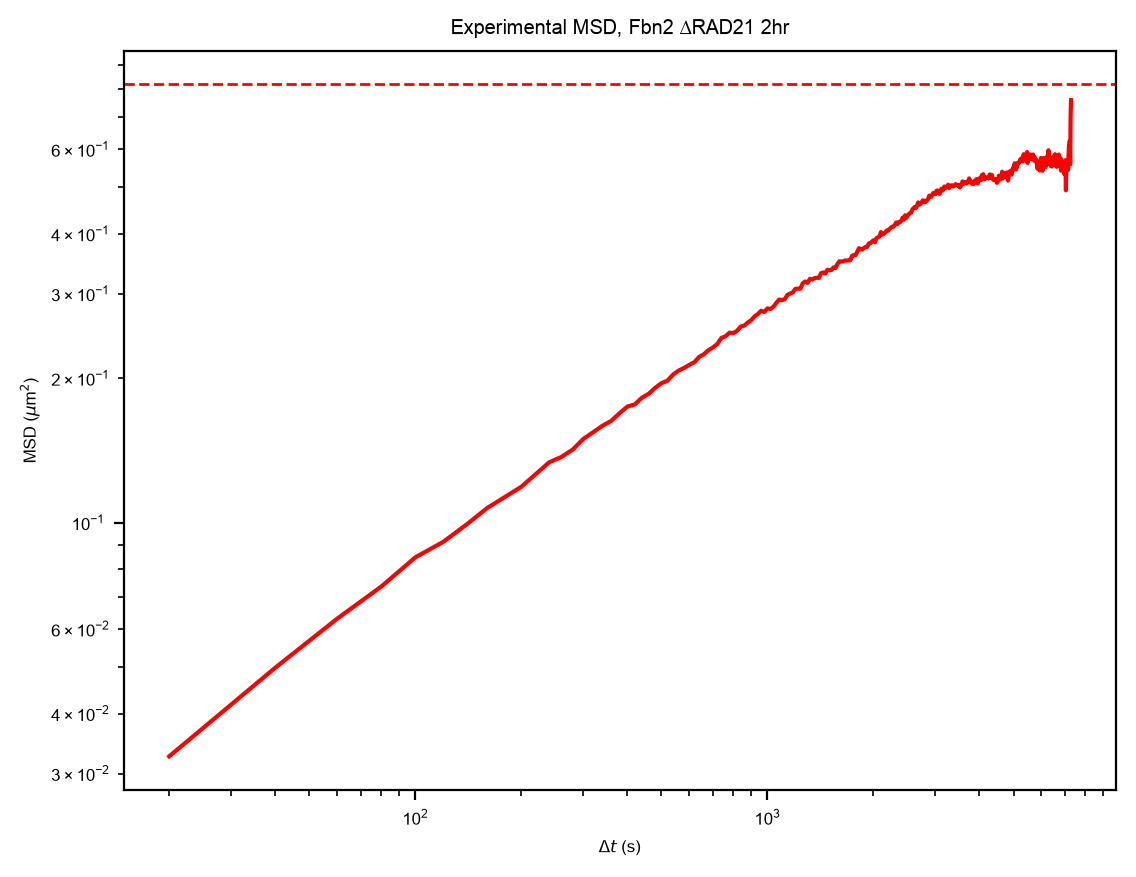

In [162]:
# Load Simon's data
file = '/mnt/md0/jjusuf/absloopquant/2022_Fbn2_full_data.h5'

data = nl.io.load.hdf5(file, 'data')

# Calculate ΔRad21 MSD
data.makeSelection(['Rad21', '2hr'], logic=all)
msd = nl.analysis.MSD(data)

frame_duration = 20  # in seconds

# Plotting
delta_t_Fbn2 = np.arange(1, len(msd))*frame_duration
msd_Fbn2 = msd[1:]
plt.plot(delta_t_Fbn2, msd_Fbn2-2*0.203**2, color='red')
plt.axhline(y=0.82, linestyle='--', color='red', linewidth=1, zorder=-1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Delta t$ (s)')
plt.ylabel(r'MSD ($\mu$m$^2$)')
plt.title('Experimental MSD, Fbn2 ∆RAD21 2hr')
plt.show()


In [129]:
# load my data
files_no_LE_no_EP = list_URIs('/mnt/md1/jjusuf/polysim/outputs/calibration3D/trajectory0007_npoly70000_nchr1_dens0.3_noLEF_dt40')
print(f'{len(files_no_LE_no_EP)} blocks found')


36000 blocks found


In [130]:
# define region, calculate my MSDs

region_size = 2000
num_chroms = 1
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size

block_start = 20000
block_end = 23000
block_step = 10

pos1 = 500
pos2 = 1015

files_to_use = files_no_LE_no_EP
timesteps_per_block = 40*500  # how many simulation timesteps per SAVE block (from the simulation code)

blocks_to_sample = np.arange(block_start, block_end, block_step)
disp_vectors = np.zeros((len(blocks_to_sample), num_regions, 3))
for i, block_num in enumerate(blocks_to_sample):
    uri = load_URI(files_to_use[block_num])
    block_data = uri['pos']  # use the one with no LE or EP
    disp_vectors[i,:,:] = block_data[region_starts+pos2]-block_data[region_starts+pos1]

convergent_value = 2*np.square(disp_vectors).sum(2).mean()  # 2*<R^2>, the value that the MSD should converge to
print(f'2<R^2> = {convergent_value}')

msd_df = pd.DataFrame(columns=['delta_t','msd'])
for i, offset in enumerate(np.arange(1, (block_end-block_start)//block_step)):
    msd = np.square(disp_vectors[offset:,:,:]-disp_vectors[:-offset,:,:]).sum(2).mean()
    msd_df.loc[i, 'delta_t'] = offset * block_step * timesteps_per_block
    msd_df.loc[i, 'msd'] = msd


2<R^2> = 1666.0455287180703


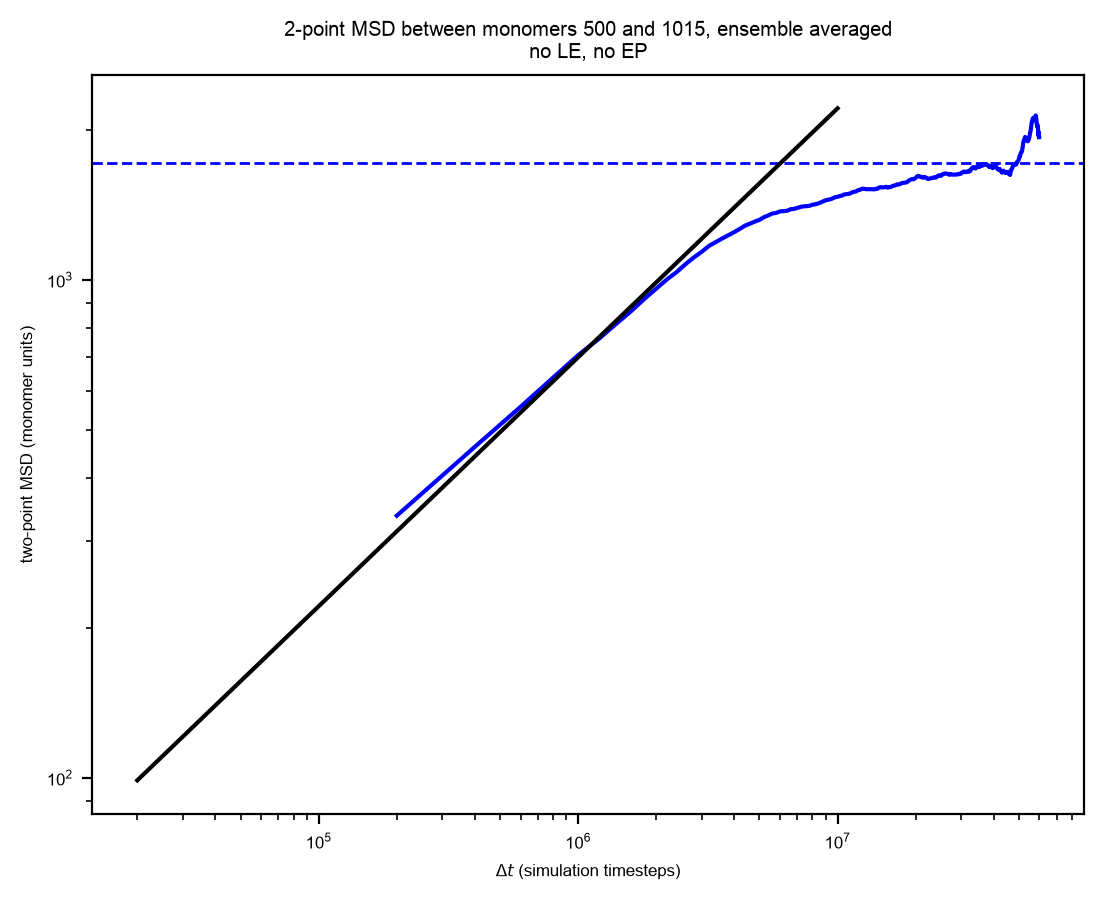

In [106]:
fig, ax = plt.subplots()
ax.plot(msd_df['delta_t'], msd_df['msd'], color='blue')
ax.axhline(y=convergent_value, linestyle='--', color='blue', linewidth=1, zorder=-1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\Delta t$ (simulation timesteps)')
ax.set_ylabel('two-point MSD (monomer units)');
ax.set_title(f'2-point MSD between monomers {pos1} and {pos2}, ensemble averaged\nno LE, no EP');
x = np.array([2e4, 1e7])
ax.plot(x,0.7*x**0.5, color='black')


In [81]:
print(np.sqrt(0.868/convergent_value))  # best monomer size (µm)


0.02208587346584028


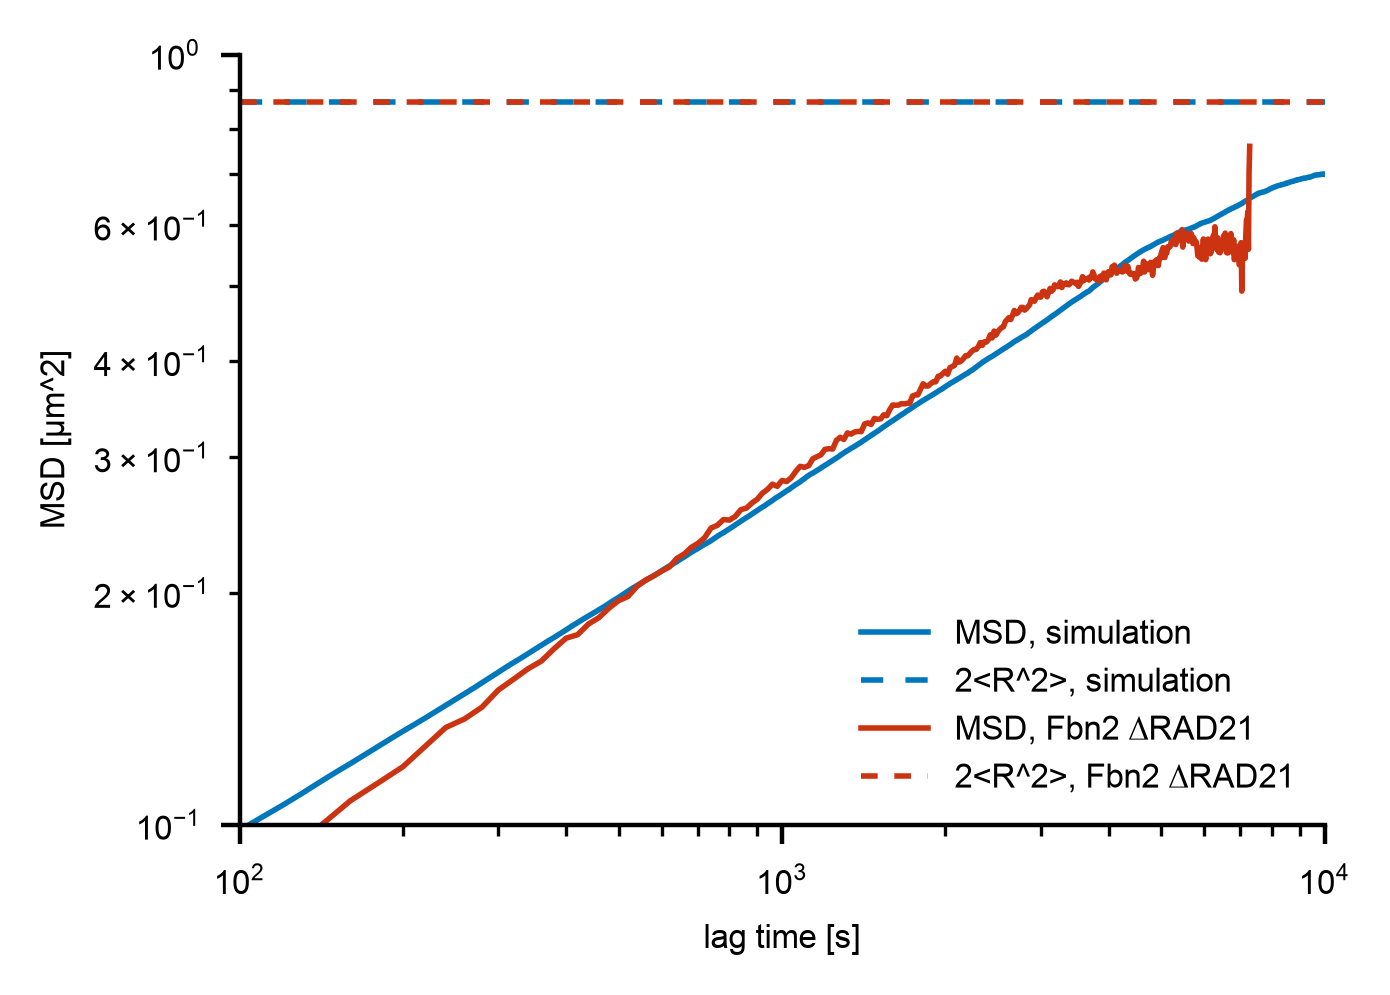

In [83]:
# fitting

monomer_size_um = 0.0221
sim_timestep_duration = 0.0005

msd_Fbn2_loc_err_corr = msd_Fbn2 - 2*0.203**2

delta_t_sim = msd_df['delta_t'] * sim_timestep_duration
msd_sim = msd_df['msd'] * (monomer_size_um)**2
convergent_value_sim = convergent_value * (monomer_size_um)**2

fig, ax = plt.subplots(figsize=(3.5,2.5),dpi=200)
ax.plot(delta_t_sim, msd_sim, color='#0077bb', linewidth=1)
ax.axhline(y=convergent_value_sim, linestyle='--', color='#0077bb', linewidth=1, zorder=-1, dashes=[4,4]);
ax.plot(delta_t_Fbn2, msd_Fbn2_loc_err_corr, color='#cc3311', linewidth=1)
ax.axhline(y=0.868, linestyle='--', color='#cc3311', linewidth=1, zorder=-1, dashes=[3,3])
ax.legend(['MSD, simulation','2<R^2>, simulation','MSD, Fbn2 ∆RAD21','2<R^2>, Fbn2 ∆RAD21'], fontsize=6, frameon=False)
ax.set_xlabel('lag time [s]');
ax.set_ylabel('MSD [\u03BCm^2]')
#ax.set_title('Comparison of simulated and experimental MSD curves\n'+f'monomer size {monomer_size_um*1e3:.0f} nm, integration timestep {sim_timestep_duration*1e6:.0f} \u03BCs', pad=8, fontsize=7);
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e2,1e4);
ax.set_ylim(1e-1,1);
ax.spines[['top','right']].set_visible(False)
# x = np.array([100, 10000])
# ax.plot(x,0.01*x**0.5, color='black')


# Bayesmsd

In [7]:
import numpy as np
from scipy.special import erfc

import bayesmsd
from noctiluca.analysis import MSD

import rouse

class TwoLocusRouseFit(bayesmsd.Fit):
    def __init__(self, data, motion_blur_f=0):
        super().__init__(data)
        self.motion_blur_f = motion_blur_f

        self.ss_order = 0

        self.parameters = {
            'log(σ²)' : bayesmsd.Parameter(bounds=(-np.inf, np.inf)),
            'log(Γ)'  : bayesmsd.Parameter(bounds=(-np.inf, np.inf)),
            'log(J)'  : bayesmsd.Parameter(bounds=(-np.inf, np.inf)),
            'log(τ)'  : bayesmsd.Parameter(bounds=(-np.inf, np.inf)),
        }

        self.parameters['log(τ)'].fix_to = TwoLocusRouseFit.fix_tau

        self.constraints = []

    @staticmethod
    def fix_tau(params):
        return 2*(params['log(J)']-params['log(Γ)']) - np.log(np.pi)

    def params2msdm(self, params):
        sigma2 = np.exp(params['log(σ²)'])
        Gamma  = np.exp(params['log(Γ)'])
        J      = np.exp(params['log(J)'])
        tau    = np.exp(params['log(τ)'])

        @bayesmsd.deco.MSDfun
        @bayesmsd.deco.imaging(noise2=sigma2,
                               f=self.motion_blur_f,
                               alpha0=0.5,
                              )
        def msd(dt, G=G, J=J, tau=tau):
            return (  2*G*np.sqrt(dt)*(1-np.exp(-tau/dt))
                    + 2*J*erfc(np.sqrt(tau/dt))   )

        return self.d*[(msd, 0)]

    def initial_params(self):
        e_msd = MSD(self.data) / self.d

        J = np.nanmean(np.concatenate([traj[:]**2 for traj in data],
                                      axis=0,
                                     ))
        G = np.nanmean(e_msd[1:5]/np.sqrt(np.arange(1, 5)))
        sigma2 = e_msd[1]/2

        return {
            'log(σ²)' : np.log(sigma2),
            'log(Γ)'  : np.log(G),
            'log(J)'  : np.log(J),
        }

    # logprior is uniform by default, so can just omit it
    

In [8]:
frame_duration = 20  # in seconds

# Plotting
delta_t_Fbn2 = np.arange(1, len(msd))*frame_duration
msd_Fbn2 = msd[1:]
plt.plot(delta_t_Fbn2, msd_Fbn2, color='red')
plt.axhline(y=0.868, linestyle='--', color='red', linewidth=1, zorder=-1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Delta t$ (s)')
plt.ylabel(r'MSD ($\mu$m$^2$)')
plt.title('Experimental MSD, Fbn2 ∆RAD21 2hr')

msd_model = rouse.twoLocusMSD(delta_t_Fbn2, Gamma=0.0049, J=0.659**2) + 2*0.203**2
plt.plot(delta_t_Fbn2, msd_model)

plt.show()


TypeError: object of type 'numpy.float64' has no len()

# synEP

In [107]:
def get_trajs(dt, condition):
    """Open trajectory data (xyz separation between E and P) and construct a list of numpy arrays,
    one array per trajectory"""
    all_trajs = np.load(f'/mnt/md1/jjusuf/synEP/data_consolidated_npz/filtered_data/{dt}s_{condition}.npz')['dataset']
    trajs = []
    for track_idx in range(len(all_trajs)):
        traj = all_trajs[track_idx,:,:]
        row_all_nan = np.all(np.isnan(traj), 1)
        non_nan_rows = np.where(~row_all_nan)[0]
        endpoint = non_nan_rows[-1] + 1 if len(non_nan_rows) > 0 else 0
        traj = traj[:endpoint]
        traj = traj / 1000  # convert to µm
        trajs.append(traj)
    return trajs

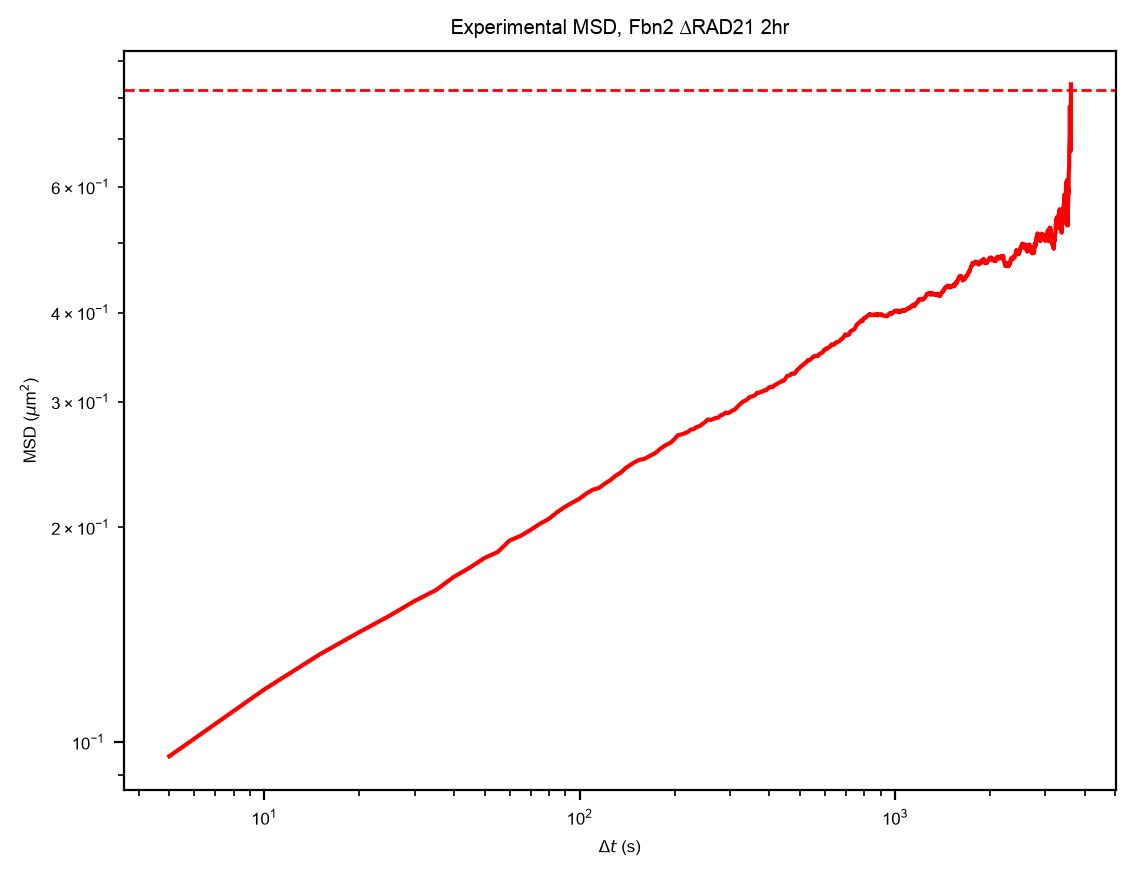

In [163]:
trajs = get_trajs(5, '340kb_Ce_Cp_IAA')
original_trajs_nl = nl.TaggedSet()
for traj_arr in trajs:
    traj = nl.Trajectory(traj_arr)
    original_trajs_nl.add(traj)

msd = nl.analysis.MSD(original_trajs_nl)

frame_duration = 5

# Plotting
delta_t_synEP = np.arange(1, len(msd))*frame_duration
msd_synEP = msd[1:]
plt.plot(delta_t_synEP, msd_synEP, color='red')
plt.axhline(y=0.82, linestyle='--', color='red', linewidth=1, zorder=-1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Delta t$ (s)')
plt.ylabel(r'MSD ($\mu$m$^2$)')
plt.title('Experimental MSD, Fbn2 ∆RAD21 2hr')
plt.show()


In [166]:
# define region, calculate my MSDs

region_size = 2000
num_chroms = 1
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size

block_start = 20000
block_end = 23000
block_step = 10

pos1 = 500
pos2 = 1015

files_to_use = files_no_LE_no_EP
timesteps_per_block = 40*500  # how many simulation timesteps per SAVE block (from the simulation code)

blocks_to_sample = np.arange(block_start, block_end, block_step)
disp_vectors = np.zeros((len(blocks_to_sample), num_regions, 3))
for i, block_num in enumerate(blocks_to_sample):
    uri = load_URI(files_to_use[block_num])
    block_data = uri['pos']  # use the one with no LE or EP
    disp_vectors[i,:,:] = block_data[region_starts+pos2]-block_data[region_starts+pos1]

convergent_value = 2*np.square(disp_vectors).sum(2).mean()  # 2*<R^2>, the value that the MSD should converge to
print(f'2<R^2> = {convergent_value}')

msd_df = pd.DataFrame(columns=['delta_t','msd'])
for i, offset in enumerate(np.arange(1, (block_end-block_start)//block_step)):
    msd = np.square(disp_vectors[offset:,:,:]-disp_vectors[:-offset,:,:]).sum(2).mean()
    msd_df.loc[i, 'delta_t'] = offset * block_step * timesteps_per_block
    msd_df.loc[i, 'msd'] = msd


2<R^2> = 1666.0455287180703


In [167]:
# define region, calculate my MSDs

region_size = 2000
num_chroms = 1
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size

block_start = 20000
block_end = 23000
block_step = 10

pos1 = 500
pos2 = 500+339

files_to_use = files_no_LE_no_EP
timesteps_per_block = 40*500  # how many simulation timesteps per SAVE block (from the simulation code)

blocks_to_sample = np.arange(block_start, block_end, block_step)
disp_vectors = np.zeros((len(blocks_to_sample), num_regions, 3))
for i, block_num in enumerate(blocks_to_sample):
    uri = load_URI(files_to_use[block_num])
    block_data = uri['pos']  # use the one with no LE or EP
    disp_vectors[i,:,:] = block_data[region_starts+pos2]-block_data[region_starts+pos1]

convergent_value = 2*np.square(disp_vectors).sum(2).mean()  # 2*<R^2>, the value that the MSD should converge to
print(f'2<R^2> = {convergent_value}')

msd_df2 = pd.DataFrame(columns=['delta_t','msd'])
for i, offset in enumerate(np.arange(1, (block_end-block_start)//block_step)):
    msd = np.square(disp_vectors[offset:,:,:]-disp_vectors[:-offset,:,:]).sum(2).mean()
    msd_df2.loc[i, 'delta_t'] = offset * block_step * timesteps_per_block
    msd_df2.loc[i, 'msd'] = msd


2<R^2> = 1268.701152626824


In [143]:
print(np.sqrt(0.6/convergent_value))  # best monomer size (µm)


0.02174682992355742


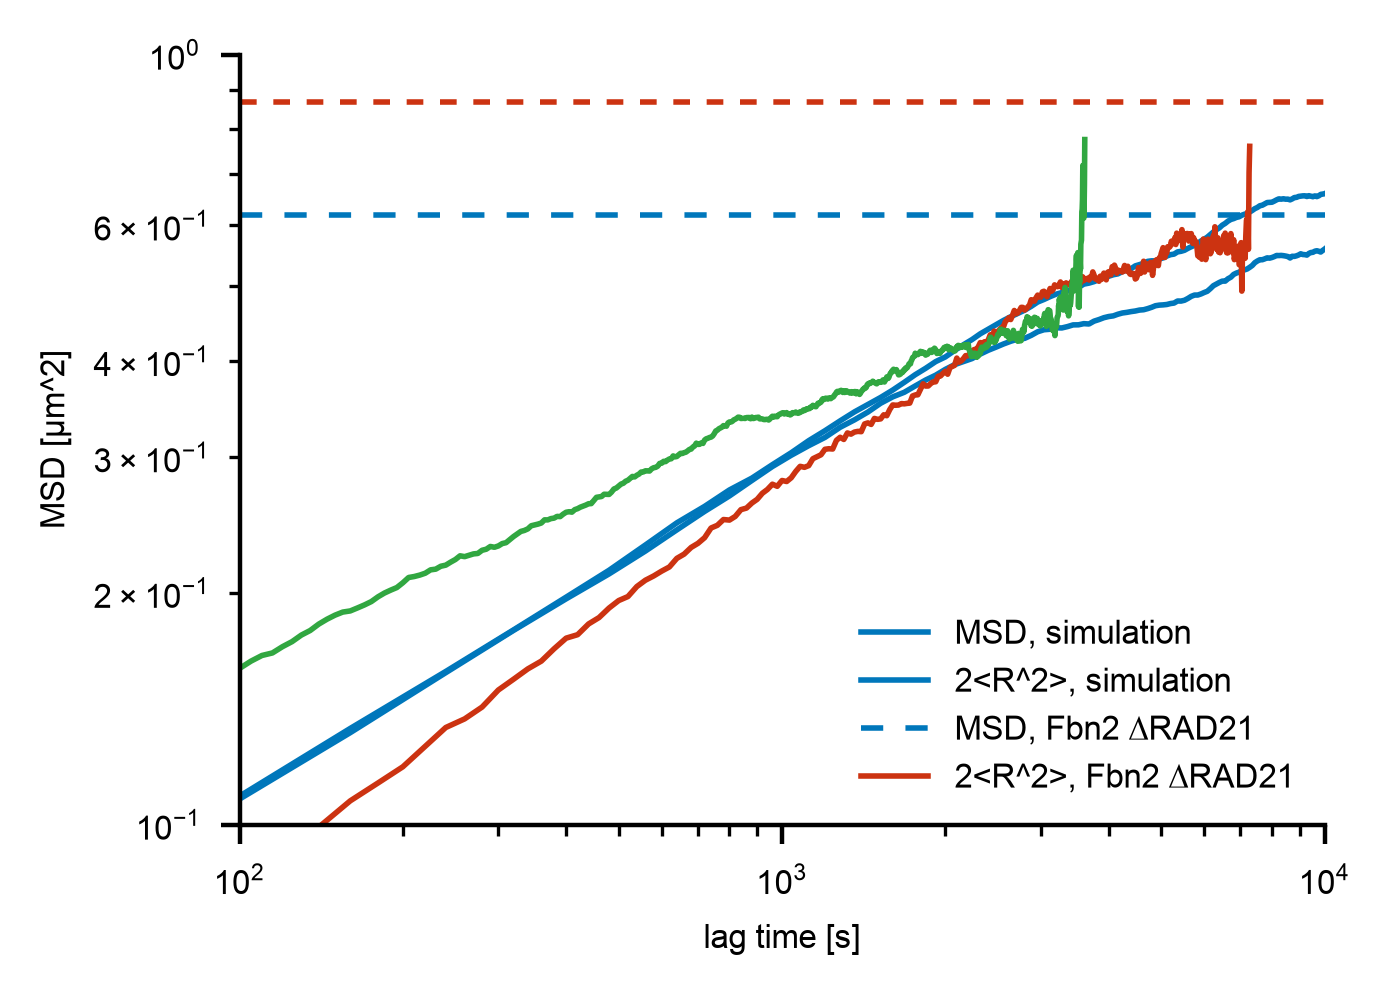

In [170]:
# fitting

monomer_size_um = 0.0221
sim_timestep_duration = 0.0004

msd_synEP_loc_err_corr = msd_synEP - 0.06
msd_Fbn2_loc_err_corr = msd_Fbn2 - 2*0.203**2

delta_t_sim = msd_df['delta_t'] * sim_timestep_duration
msd_sim = msd_df['msd'] * (monomer_size_um)**2
msd_sim2 = msd_df2['msd'] * (monomer_size_um)**2
convergent_value_sim = convergent_value * (monomer_size_um)**2

fig, ax = plt.subplots(figsize=(3.5,2.5),dpi=200)
ax.plot(delta_t_sim, msd_sim, color='#0077bb', linewidth=1)
ax.plot(delta_t_sim, msd_sim2, color='#0077bb', linewidth=1)
ax.axhline(y=convergent_value_sim, linestyle='--', color='#0077bb', linewidth=1, zorder=-1, dashes=[4,4]);
ax.plot(delta_t_Fbn2, msd_Fbn2_loc_err_corr, color='#cc3311', linewidth=1)
ax.axhline(y=0.868, linestyle='--', color='#cc3311', linewidth=1, zorder=-1, dashes=[3,3])
ax.plot(delta_t_synEP, msd_synEP_loc_err_corr, color="#31a741", linewidth=1)
# ax.axhline(y=0.868, linestyle='--', color='#31a741', linewidth=1, zorder=-1, dashes=[3,3])
ax.legend(['MSD, simulation','2<R^2>, simulation','MSD, Fbn2 ∆RAD21','2<R^2>, Fbn2 ∆RAD21'], fontsize=6, frameon=False)
ax.set_xlabel('lag time [s]');
ax.set_ylabel('MSD [\u03BCm^2]')
#ax.set_title('Comparison of simulated and experimental MSD curves\n'+f'monomer size {monomer_size_um*1e3:.0f} nm, integration timestep {sim_timestep_duration*1e6:.0f} \u03BCs', pad=8, fontsize=7);
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e2,1e4);
ax.set_ylim(1e-1,1);
ax.spines[['top','right']].set_visible(False)
# x = np.array([100, 10000])
# ax.plot(x,0.01*x**0.5, color='black')
